In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.models import SmallCNN
from src.initialization import initialize_model
from src.sparsity_masks import initialize_masks, apply_masks
from src.data import get_mnist_loaders


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [3]:

train_loader, test_loader = get_mnist_loaders(batch_size=64)

In [4]:
# Hyperparameters
batch_size = 64
learning_rate = 0.005
num_epochs = 5


## dense + Gaussian init

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
model = SmallCNN().to(device)

In [7]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [8]:
# Training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/5], Loss: 0.2127
Epoch [2/5], Loss: 0.0920
Epoch [3/5], Loss: 0.0732
Epoch [4/5], Loss: 0.0671
Epoch [5/5], Loss: 0.0612


In [9]:
# Evaluation
model.eval()
correct = 0
total = 0

wrong_images = []
wrong_labels = []
wrong_preds = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        # incorrect predictions
        incorrect = predicted != labels
        wrong_images.extend(images[incorrect].cpu())
        wrong_labels.extend(labels[incorrect].cpu())
        wrong_preds.extend(predicted[incorrect].cpu())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 97.78%


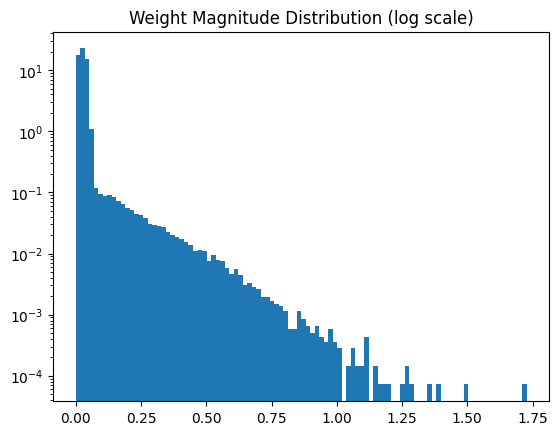

In [12]:
# plot weight values

weights = model.fc1.weight.detach().cpu().numpy().flatten()

plt.figure()
plt.hist(np.abs(weights), bins=100, density=True)
plt.yscale("log")
plt.title("Weight Magnitude Distribution (log scale)")
plt.show()